In [ ]:
# Final Deliverables (EDA Artifacts)
# ✅ Feature Engineering Columns
# ✅ Missing Value % Report
# ✅ Missing Value Strategy
# ✅ Mean, Median, Mode, Standard Deviation
# ✅ Time Series Plot
# ✅ Trend Analysis
# ✅ Outlier Detection
# ✅ Boxplot
# ✅ Period Detection
# ✅ Seasonal Decomposition
# ✅ Stationarity Test (ADF)
# ✅ ACF Plot
# ✅ PACF Plot
# ✅ Final EDA Report

importing data set



In [ ]:
df = pd.read_csv('sakshi_ppg_20260611T074737_len148s.csv')

print(df.head())
print(df.info())

   seq  timestamp_ms    red      ir  red_corrected  ir_corrected
0    1        135093  40603  100950     -10.788063     -4.396235
1    2        135113  40616  100938       2.142789    -15.105669
2    3        135133  40603  100945     -12.051503     -7.542110
3    4        135153  40612  100939      -0.769166    -14.245303
4    5        135173  40621  100933       8.087457    -20.552190
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7423 entries, 0 to 7422
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   seq            7423 non-null   int64  
 1   timestamp_ms   7423 non-null   int64  
 2   red            7423 non-null   int64  
 3   ir             7423 non-null   int64  
 4   red_corrected  7423 non-null   float64
 5   ir_corrected   7423 non-null   float64
dtypes: float64(2), int64(4)
memory usage: 348.1 KB
None


Feature Engineering Columns


In [ ]:
# Timestamp conversion
df['timestamp_ms'] = pd.to_datetime(df['timestamp_ms'], unit='ms')

# Time Features
df['year'] = df['timestamp_ms'].dt.year
df['month'] = df['timestamp_ms'].dt.month
df['day'] = df['timestamp_ms'].dt.day
df['hour'] = df['timestamp_ms'].dt.hour
df['minute'] = df['timestamp_ms'].dt.minute
df['second'] = df['timestamp_ms'].dt.second
df['day_of_week'] = df['timestamp_ms'].dt.dayofweek

signal_cols = [
    'red',
    'ir',
    'red_corrected',
    'ir_corrected'
]

for col in signal_cols:

    df[f'{col}_lag1'] = df[col].shift(1)

    df[f'{col}_lag5'] = df[col].shift(5)

    df[f'{col}_rolling_mean'] = (
        df[col].rolling(5).mean()
    )

    df[f'{col}_rolling_std'] = (
        df[col].rolling(5).std()
    )

print("Feature Engineering Completed")

Feature Engineering Completed


Missing Percentage & Imputation Strategy

In [ ]:
signal_cols = [
    'red',
    'ir',
    'red_corrected',
    'ir_corrected'
]

missing_report = pd.DataFrame()

for col in signal_cols:

    missing_count = df[col].isna().sum()

    missing_pct = (
        missing_count / len(df)
    ) * 100

    missing_report.loc[col,
                       'Missing Count'] = missing_count

    missing_report.loc[col,
                       'Missing %'] = round(
                           missing_pct,2
                       )

print(missing_report)

# Imputation

for col in signal_cols:

    df[col] = (
        df[col]
        .interpolate()
        .ffill()
        .bfill()
    )

print("\nStrategy Used:")
print("Interpolation -> Forward Fill -> Backward Fill")

               Missing Count  Missing %
red                      0.0        0.0
ir                       0.0        0.0
red_corrected            0.0        0.0
ir_corrected             0.0        0.0

Strategy Used:
Interpolation -> Forward Fill -> Backward Fill


Time Series Plot

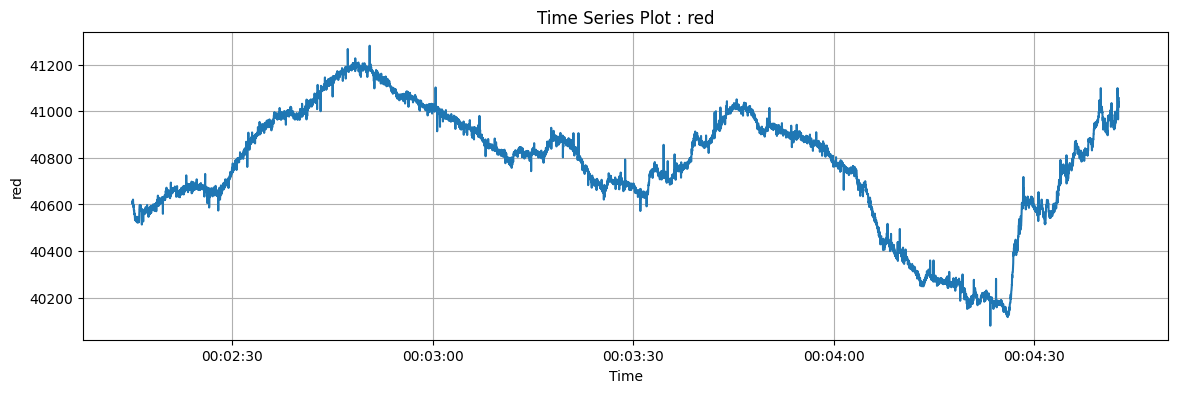

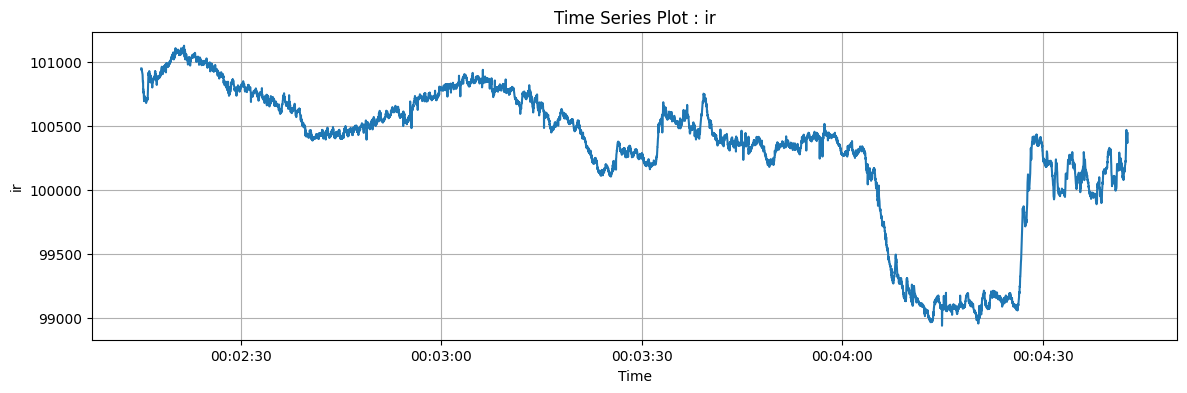

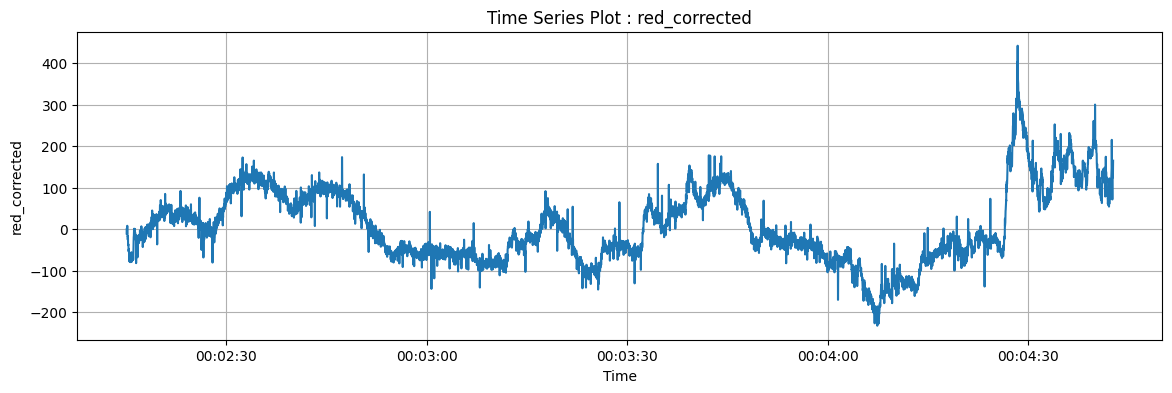

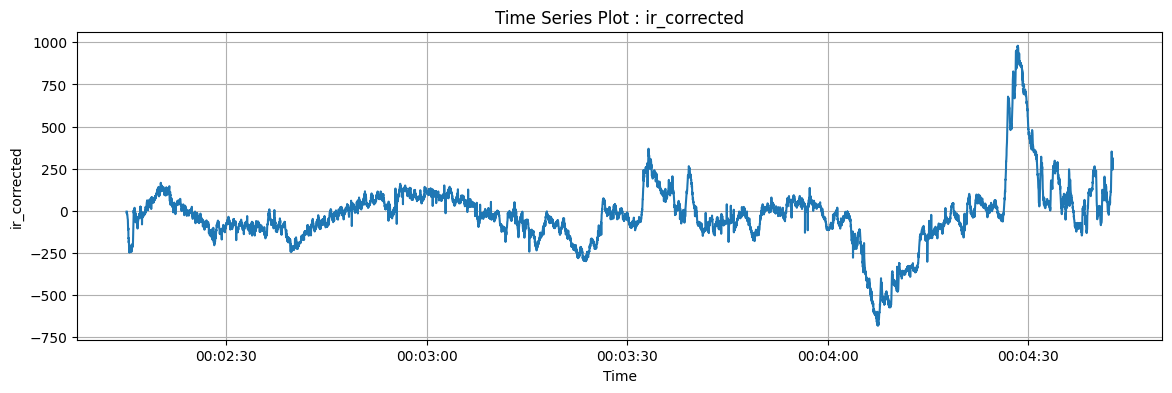

In [ ]:
import matplotlib.pyplot as plt

signal_cols = [
    'red',
    'ir',
    'red_corrected',
    'ir_corrected'
]

for col in signal_cols:

    plt.figure(figsize=(14,4))

    plt.plot(
        df['timestamp_ms'],
        df[col]
    )

    plt.title(
        f'Time Series Plot : {col}'
    )

    plt.xlabel("Time")
    plt.ylabel(col)

    plt.grid(True)

    plt.show()

Decomposition Analysis


In [ ]:
signal_cols = [
    'red',
    'ir',
    'red_corrected',
    'ir_corrected'
]

stats_df = pd.DataFrame()

for col in signal_cols:

    stats_df.loc[col,'Mean'] = df[col].mean()
    stats_df.loc[col,'Median'] = df[col].median()
    stats_df.loc[col,'Mode'] = df[col].mode()[0]
    stats_df.loc[col,'Std Dev'] = df[col].std()


print(stats_df)

                        Mean         Median           Mode     Std Dev
red             40766.814226   40814.000000   41017.000000  253.111665
ir             100317.870538  100425.000000  100373.000000  535.399046
red_corrected       7.390210     -13.113405    -232.529984   88.544662
ir_corrected      -22.088821     -26.099895    -681.463413  186.457236


Bonu task: superimpose IR and red graphs after normalisation/standardisation so that you can see the variability in peak positions

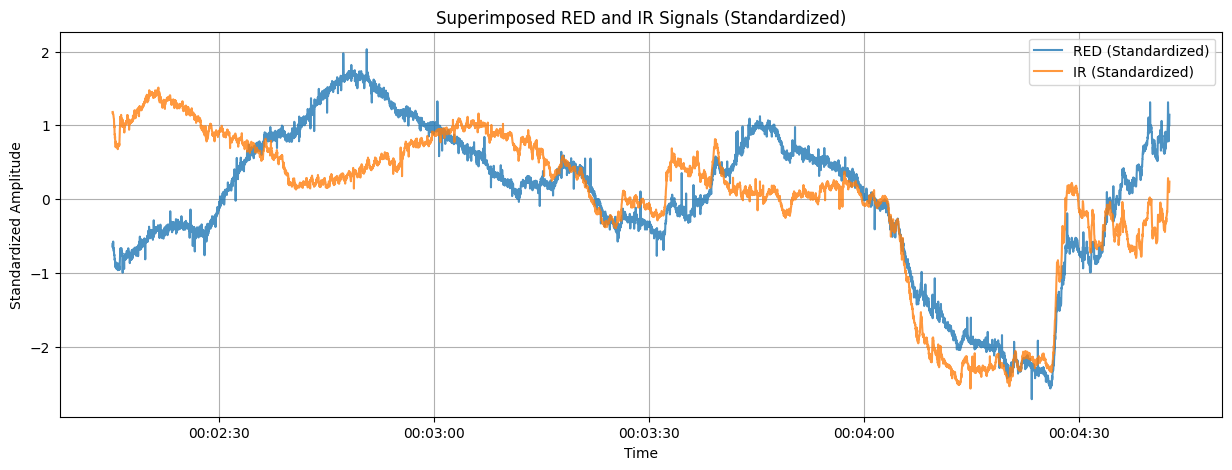

In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

signals = df[['red', 'ir']]

scaler = StandardScaler()

scaled_signals = scaler.fit_transform(signals)

df['red_std'] = scaled_signals[:, 0]
df['ir_std'] = scaled_signals[:, 1]

plt.figure(figsize=(15,5))

plt.plot(
    df['timestamp_ms'],
    df['red_std'],
    label='RED (Standardized)',
    alpha=0.8
)

plt.plot(
    df['timestamp_ms'],
    df['ir_std'],
    label='IR (Standardized)',
    alpha=0.8
)

plt.title(
    'Superimposed RED and IR Signals (Standardized)'
)

plt.xlabel('Time')
plt.ylabel('Standardized Amplitude')

plt.legend()
plt.grid(True)

plt.show()

Both RED and IR signals were standardized and plotted on the same scale.

The superimposed plot enables direct comparison of peak positions.

Observations:
• Peak locations largely coincide, indicating proper sensor synchronization.
• Minor variations in peak amplitudes are visible.
• IR signal appears smoother than RED signal.
• No significant temporal shift between corresponding peaks.
• The comparison confirms consistent pulse detection across both channels.

Shape: (7423, 6)
Forecasting: red

MAE  : 131.4260
RMSE : 191.7749


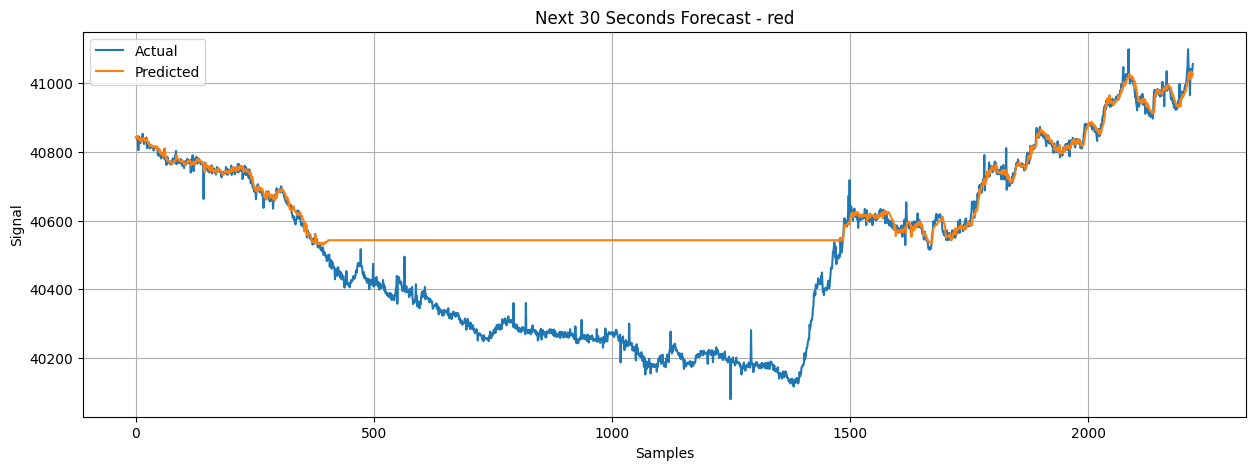

In [ ]:
# ==========================================
# NEXT 30 SECONDS FORECASTING + MAE + RMSE
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("sakshi_ppg_20260611T074737_len148s.csv")

print("Shape:", df.shape)

# ------------------------------------
# Select signal column
# ------------------------------------
signal_col = df.columns[-4]   # Change if needed

signal = df[signal_col].values

print("Forecasting:", signal_col)

# ------------------------------------
# Create lag features
# ------------------------------------
window = 20

X = []
y = []

for i in range(window, len(signal)):
    X.append(signal[i-window:i])
    y.append(signal[i])

X = np.array(X)
y = np.array(y)

# ------------------------------------
# Train-Test Split
# ------------------------------------
split = int(len(X)*0.7)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# ------------------------------------
# Train Model
# ------------------------------------
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ------------------------------------
# Predict
# ------------------------------------
y_pred = model.predict(X_test)

# ------------------------------------
# Metrics
# ------------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"\nMAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

# ------------------------------------
# Estimate sampling rate
# ------------------------------------
sampling_rate = 100  # modify if known

forecast_samples = 30 * sampling_rate

forecast_samples = min(
    forecast_samples,
    len(y_test)
)

# ------------------------------------
# Plot next 30 sec forecast
# ------------------------------------
plt.figure(figsize=(15,5))

plt.plot(
    y_test[:forecast_samples],
    label="Actual"
)

plt.plot(
    y_pred[:forecast_samples],
    label="Predicted"
)

plt.title(f"Next 30 Seconds Forecast - {signal_col}")
plt.xlabel("Samples")
plt.ylabel("Signal")
plt.legend()
plt.grid(True)

plt.show()